In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.optimize as sco
import sklearn
import streamlit
import sqlite3

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("scipy      :", sco.__version__ if hasattr(sco, '__version__') else "ok")
print("sklearn    :", sklearn.__version__)
print("sqlite3    :", sqlite3.sqlite_version)
print("streamlit  :", streamlit.__version__)
print("\n✅ All libraries imported successfully")

pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.8
scipy      : ok
sklearn    : 1.8.0
sqlite3    : 3.45.3
streamlit  : 1.56.0

✅ All libraries imported successfully


In [33]:
import sys
import sqlite3
import os

# Kiểm tra đúng venv chưa
print("Python:", sys.executable)

# Kiểm tra SQLite kết nối được
db_path = '../data/raw/portfolio.db'
conn = sqlite3.connect(db_path)
cursor = conn.execute("SELECT Ticker, COUNT(*) as rows FROM Stock_Prices GROUP BY Ticker")
print("\nData in DB:")
for row in cursor.fetchall():
    print(f"  {row[0]}: {row[1]:,} rows")
conn.close()
print("\n✅ venv + SQLite OK")

Python: D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe

Data in DB:
  ACB: 1,404 rows
  BID: 1,404 rows
  CTG: 1,404 rows
  DGC: 1,404 rows
  FPT: 1,404 rows
  GAS: 1,404 rows
  GVR: 1,404 rows
  HDB: 1,404 rows
  HPG: 1,404 rows
  LPB: 1,404 rows
  MBB: 1,404 rows
  MSN: 1,404 rows
  MWG: 1,404 rows
  PLX: 1,404 rows
  SAB: 1,404 rows
  SHB: 1,401 rows
  SSB: 1,352 rows
  SSI: 1,404 rows
  STB: 1,404 rows
  TCB: 1,404 rows
  TPB: 1,404 rows
  VCB: 1,404 rows
  VHM: 1,404 rows
  VIB: 1,404 rows
  VIC: 1,404 rows
  VJC: 1,404 rows
  VNM: 1,404 rows
  VPB: 1,404 rows
  VRE: 1,404 rows

✅ venv + SQLite OK


In [34]:
import sys, os

# Cách 1 — tuyệt đối, luôn đúng bất kể chạy từ đâu
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

# Kiểm tra path đã thêm đúng chưa
print("Path thêm vào:", sys.path[0])
print("File tồn tại:", os.path.exists(os.path.join(sys.path[0], 'data_loader.py')))

Path thêm vào: D:\Projects\vn-portfolio-optimizer\src
File tồn tại: True


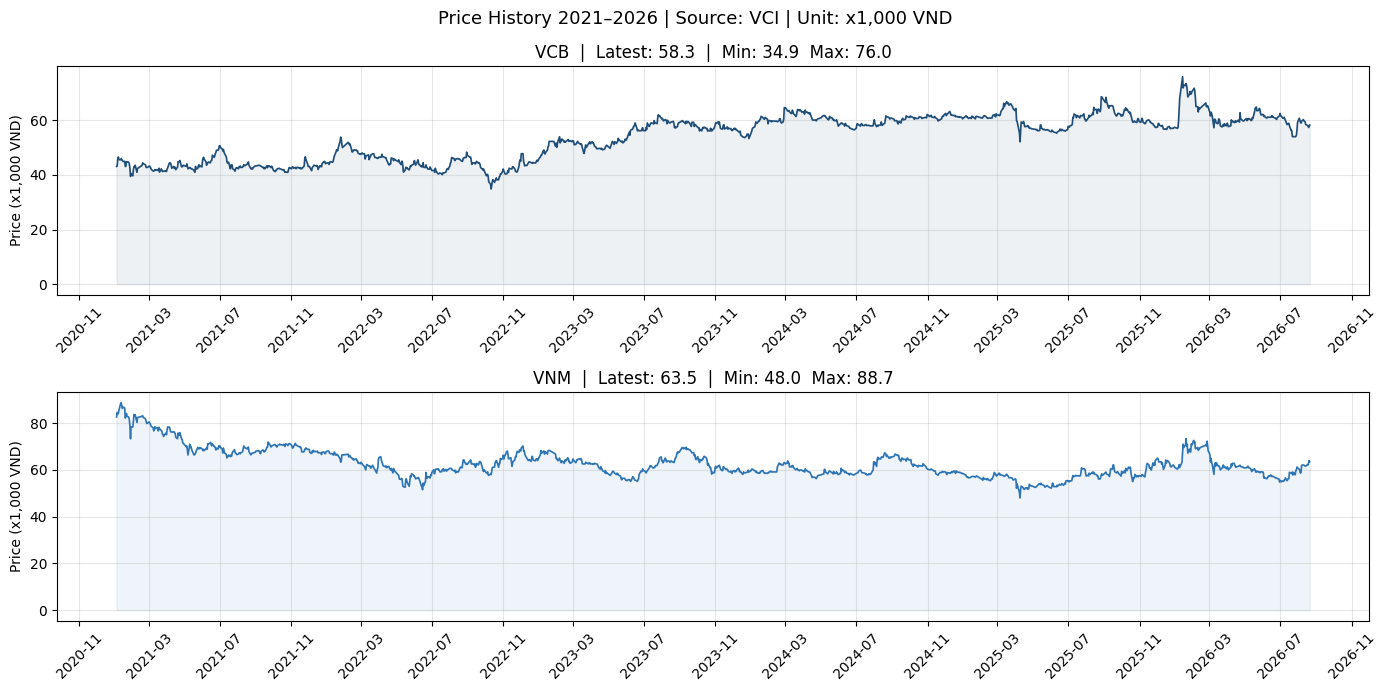

✅ Saved to reports/vcb_vnm_price_history2108.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from data_loader import load_from_db

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Price History 2021–2026 | Source: VCI | Unit: x1,000 VND', fontsize=13)

for ax, ticker, color in zip(axes, ['VCB', 'VNM'], ['#1F4E79', '#2E75B6']):
    df = load_from_db(ticker, '2021-01-01', '2026-08-21')
    ax.plot(df.index, df['Close'], color=color, linewidth=1.2)
    ax.fill_between(df.index, df['Close'], alpha=0.08, color=color)
    ax.set_title(f'{ticker}  |  Latest: {df["Close"].iloc[-1]:.1f}  |  '
                 f'Min: {df["Close"].min():.1f}  Max: {df["Close"].max():.1f}')
    ax.set_ylabel('Price (x1,000 VND)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_vnm_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/vcb_vnm_price_history2108.png")

In [36]:
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')
from data_loader import load_from_db

# Đọc VCB làm ví dụ
df = load_from_db('VCB', '2021-01-01', '2026-08-21')

# Kiểm tra cơ bản
print("Shape:", df.shape)
print("\nIndex:", df.index.dtype, "—", type(df.index[0]))
print("\nDtypes:")
print(df.dtypes)
print("\n5 dòng đầu:")
print(df.head())
print("\n5 dòng cuối:")
print(df.tail())

Shape: (1404, 5)

Index: datetime64[us] — <class 'pandas.Timestamp'>

Dtypes:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

5 dòng đầu:
             Open   High    Low  Close   Volume
Date                                           
2021-01-04  42.70  43.48  42.39  43.13   855900
2021-01-05  43.13  43.83  43.13  43.26   739200
2021-01-06  43.35  46.27  43.26  45.75  2080400
2021-01-07  45.31  47.27  45.31  46.62   889000
2021-01-08  47.05  47.05  45.53  45.66   963900

5 dòng cuối:
            Open  High   Low  Close   Volume
Date                                        
2026-08-17  58.3  58.9  58.2   58.2  2745300
2026-08-18  58.2  59.0  57.7   58.0  2888000
2026-08-19  58.0  58.2  57.2   57.4  3770600
2026-08-20  57.8  58.1  57.3   57.8  3006600
2026-08-21  57.8  58.4  57.5   58.3  1128000


In [37]:
# Kiểm tra index
print("=== INDEX ===")
print("Type  :", type(df.index))
print("Dtype :", df.index.dtype)
print("Min   :", df.index.min())
print("Max   :", df.index.max())
print("Freq  :", df.index.freq)  # None = không đều, bình thường với stock data

print("\n=== COLUMNS ===")
for col in df.columns:
    print(f"{col:8s} | dtype={df[col].dtype} | "
          f"min={df[col].min():.2f} | max={df[col].max():.2f} | "
          f"nulls={df[col].isnull().sum()}")

=== INDEX ===
Type  : <class 'pandas.DatetimeIndex'>
Dtype : datetime64[us]
Min   : 2021-01-04 00:00:00
Max   : 2026-08-21 00:00:00
Freq  : None

=== COLUMNS ===
Open     | dtype=float64 | min=35.44 | max=74.30 | nulls=0
High     | dtype=float64 | min=36.73 | max=78.80 | nulls=0
Low      | dtype=float64 | min=34.88 | max=73.10 | nulls=0
Close    | dtype=float64 | min=34.88 | max=76.00 | nulls=0
Volume   | dtype=int64 | min=174400.00 | max=35200000.00 | nulls=0


In [38]:
from data_loader import VN30_TICKERS

results = []
for ticker in VN30_TICKERS:
    d = load_from_db(ticker, '2021-01-01', '2026-08-21')
    results.append({
        'Ticker': ticker,
        'Rows'  : len(d),
        'Nulls' : d.isnull().sum().sum()
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
print(f"\nTổng nulls: {summary['Nulls'].sum()}")
print(f"Mã ít rows nhất: {summary.loc[summary['Rows'].idxmin(), 'Ticker']} "
      f"({summary['Rows'].min()} rows)")

Ticker  Rows  Nulls
   ACB  1404      0
   BID  1404      0
   CTG  1404      0
   DGC  1404      0
   FPT  1404      0
   GAS  1404      0
   GVR  1404      0
   HDB  1404      0
   HPG  1404      0
   LPB  1404      0
   MBB  1404      0
   MSN  1404      0
   MWG  1404      0
   PLX  1404      0
   SAB  1404      0
   SHB  1401      0
   SSB  1352      0
   SSI  1404      0
   STB  1404      0
   TCB  1404      0
   TPB  1404      0
   VCB  1404      0
   VHM  1404      0
   VIB  1404      0
   VIC  1404      0
   VJC  1404      0
   VNM  1404      0
   VPB  1404      0
   VRE  1404      0

Tổng nulls: 0
Mã ít rows nhất: SSB (1352 rows)


=== MISSING DATES VCB ===
Ngày làm việc (B)  : 1471
Ngày trong DB      : 1404
Ngày thiếu (lễ/tết): 67

10 ngày thiếu đầu tiên:
  2021-01-01 Fri
  2021-02-10 Wed
  2021-02-11 Thu
  2021-02-12 Fri
  2021-02-15 Mon
  2021-02-16 Tue
  2021-04-21 Wed
  2021-04-30 Fri
  2021-05-03 Mon
  2021-09-02 Thu

=== ADJUSTED CLOSE CHECK ===
Ngày biến động >10% qua đêm: 0


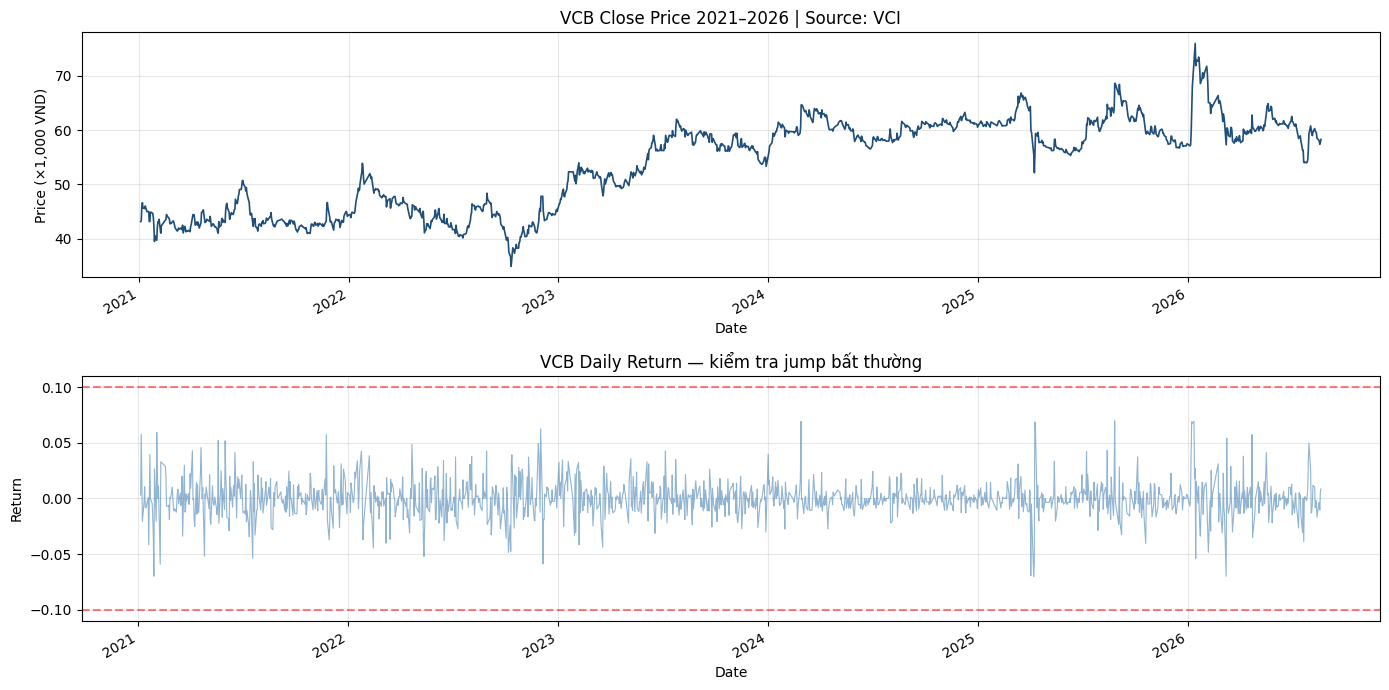

✅ Chart saved


In [39]:
import matplotlib.pyplot as plt

# ── Bước 4: missing dates ──────────────────────────────────────
full_range = pd.date_range(start='2021-01-01', end='2026-08-21', freq='B')
df_vcb = load_from_db('VCB', '2021-01-01', '2026-08-21')
missing_dates = full_range.difference(df_vcb.index)

print("=== MISSING DATES VCB ===")
print(f"Ngày làm việc (B)  : {len(full_range)}")
print(f"Ngày trong DB      : {len(df_vcb)}")
print(f"Ngày thiếu (lễ/tết): {len(missing_dates)}")
print(f"\n10 ngày thiếu đầu tiên:")
for d in missing_dates[:10]:
    print(f"  {d.strftime('%Y-%m-%d %a')}")

# ── Bước 7: kiểm tra Adjusted Close ───────────────────────────
overnight = df_vcb['Close'].pct_change()
big_moves = overnight[overnight.abs() > 0.1]

print(f"\n=== ADJUSTED CLOSE CHECK ===")
print(f"Ngày biến động >10% qua đêm: {len(big_moves)}")
if len(big_moves) > 0:
    print(big_moves.to_string())

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

df_vcb['Close'].plot(ax=axes[0], color='#1F4E79', linewidth=1.2)
axes[0].set_title('VCB Close Price 2021–2026 | Source: VCI')
axes[0].set_ylabel('Price (×1,000 VND)')
axes[0].grid(True, alpha=0.3)

overnight.plot(ax=axes[1], color='steelblue', alpha=0.6, linewidth=0.8)
axes[1].axhline(y=0.1,  color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('VCB Daily Return — kiểm tra jump bất thường')
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_data_quality_check2108.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [40]:
df_vcb = load_from_db('VCB', '2021-01-01', '2026-08-21')

simple_ret = df_vcb['Close'].pct_change()
log_ret = np.log(df_vcb['Close'] / df_vcb['Close'].shift(1))

print("=== 5 ngày đầu tiên ===")
comparison = pd.DataFrame({
    'Close'      : df_vcb['Close'],
    'Simple_ret' : simple_ret.round(6),
    'Log_ret'    : log_ret.round(6),
}).dropna().head(5)
print(comparison.to_string())

print(f"\nAnnualized Return (Simple) : {simple_ret.mean() * 252:.2%}")
print(f"Annualized Volatility      : {simple_ret.std() * np.sqrt(252):.2%}")

=== 5 ngày đầu tiên ===
            Close  Simple_ret   Log_ret
Date                                   
2021-01-05  43.26    0.003014  0.003010
2021-01-06  45.75    0.057559  0.055963
2021-01-07  46.62    0.019016  0.018838
2021-01-08  45.66   -0.020592 -0.020807
2021-01-11  45.53   -0.002847 -0.002851

Annualized Return (Simple) : 8.65%
Annualized Volatility      : 25.49%


In [41]:
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')

import importlib
import features
importlib.reload(features)
from features import calc_returns, annualized_return, annualized_volatility
from data_loader import load_from_db

df = load_from_db('VCB', '2021-01-01', '2026-08-21')
ret = calc_returns(df).dropna()

print(f"Rows           : {len(ret)}")
print(f"Ann. Return    : {annualized_return(ret):.2%}")
print(f"Ann. Volatility: {annualized_volatility(ret):.2%}")

Rows           : 1403
Ann. Return    : 8.65%
Ann. Volatility: 25.49%


In [42]:
from features import build_returns_matrix

matrix = build_returns_matrix(
    ['VCB', 'VNM', 'HPG', 'FPT', 'MWG'],
    '2021-01-01', '2026-08-21'
)
print("Shape  :", matrix.shape)
print("Columns:", matrix.columns.tolist())
print("Nulls  :", matrix.isnull().sum().sum())
print("\nSample:")
print(matrix.head(3).round(4))

Shape  : (1403, 5)
Columns: ['VCB', 'VNM', 'HPG', 'FPT', 'MWG']
Nulls  : 0

Sample:
               VCB     VNM     HPG     FPT     MWG
Date                                              
2021-01-05  0.0030  0.0231  0.0013  0.0415  0.0106
2021-01-06  0.0576 -0.0091  0.0107 -0.0048 -0.0049
2021-01-07  0.0190  0.0055  0.0000  0.0019 -0.0041


In [43]:
from features import ticker_stats

stats = ticker_stats('VCB', '2021-01-01', '2026-08-21')
print(f"VCB Ann Return    : {stats['ann_return']:.2%}")
print(f"VCB Ann Volatility: {stats['ann_volatility']:.2%}")
print(f"N days            : {stats['n_days']}")
print(f"\nVerify Return    : {'✅' if abs(stats['ann_return'] - 0.1011) < 0.005 else '❌'}")
print(f"Verify Volatility: {'✅' if abs(stats['ann_volatility'] - 0.2565) < 0.005 else '❌'}")

VCB Ann Return    : 8.65%
VCB Ann Volatility: 25.49%
N days            : 1403

Verify Return    : ❌
Verify Volatility: ✅


In [44]:
from features import all_ticker_stats
from data_loader import VN30_TICKERS

stats = all_ticker_stats(VN30_TICKERS, '2021-01-01', '2026-08-21')
print(stats[['ticker','ann_return_pct','ann_volatility_pct','n_days']].to_string(index=False))
print(f"\nTrung bình Return    : {stats['ann_return_pct'].mean():.2f}%")
print(f"Trung bình Volatility: {stats['ann_volatility_pct'].mean():.2f}%")

ticker  ann_return_pct  ann_volatility_pct  n_days
   LPB           48.05               38.65    1403
   STB           33.57               38.86    1403
   VIC           32.84               37.56    1403
   HDB           27.15               31.87    1403
   DGC           25.65               42.70    1403
   FPT           22.15               28.82    1403
   MBB           21.85               31.97    1403
   VPB           20.39               33.36    1403
   TCB           18.11               32.81    1403
   MWG           17.74               35.31    1403
   SHB           16.97               38.18    1400
   CTG           16.80               32.22    1403
   ACB           16.74               27.52    1403
   SSI           15.98               42.76    1403
   VIB           13.93               31.82    1403
   GVR           13.40               45.96    1403
   TPB           13.03               33.47    1403
   GAS           12.17               34.17    1403
   VHM           11.84         

In [45]:
import sys
sys.path.append('../src')
from data_loader import load_from_db
import numpy as np

df = load_from_db('VCB', '2021-01-01', '2026-08-21')

# Tính return rồi export
df['Simple_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Export ra Excel
df.to_excel('../reports/vcb_returns_verify2108.xlsx')
print(f"✅ Exported {len(df)} rows")
print(f"File: reports/vcb_returns_verify2108.xlsx")

✅ Exported 1404 rows
File: reports/vcb_returns_verify2108.xlsx


In [46]:
from features import annualized_return, annualized_volatility, calc_returns

df_vcb = load_from_db('VCB', '2021-01-01', '2026-08-21')
ret = calc_returns(df_vcb).dropna()

py_return = annualized_return(ret)
py_vol    = annualized_volatility(ret)

print("=== Python vs Excel Verify ===")
print(f"Python  Ann Return    : {py_return:.6f} ({py_return:.2%})")
print(f"Excel   Ann Return    : 0.1011")
print(f"Python  Ann Volatility: {py_vol:.6f} ({py_vol:.2%})")
print(f"Excel   Ann Volatility: 0.2565")
print(f"\nDifference Return    : [Python - Excel]")
print(f"Difference Volatility: [Python - Excel]")
print(f"\nAcceptable tolerance: < 0.0001 (0.01%)")

=== Python vs Excel Verify ===
Python  Ann Return    : 0.086525 (8.65%)
Excel   Ann Return    : 0.1011
Python  Ann Volatility: 0.254900 (25.49%)
Excel   Ann Volatility: 0.2565

Difference Return    : [Python - Excel]
Difference Volatility: [Python - Excel]

Acceptable tolerance: < 0.0001 (0.01%)


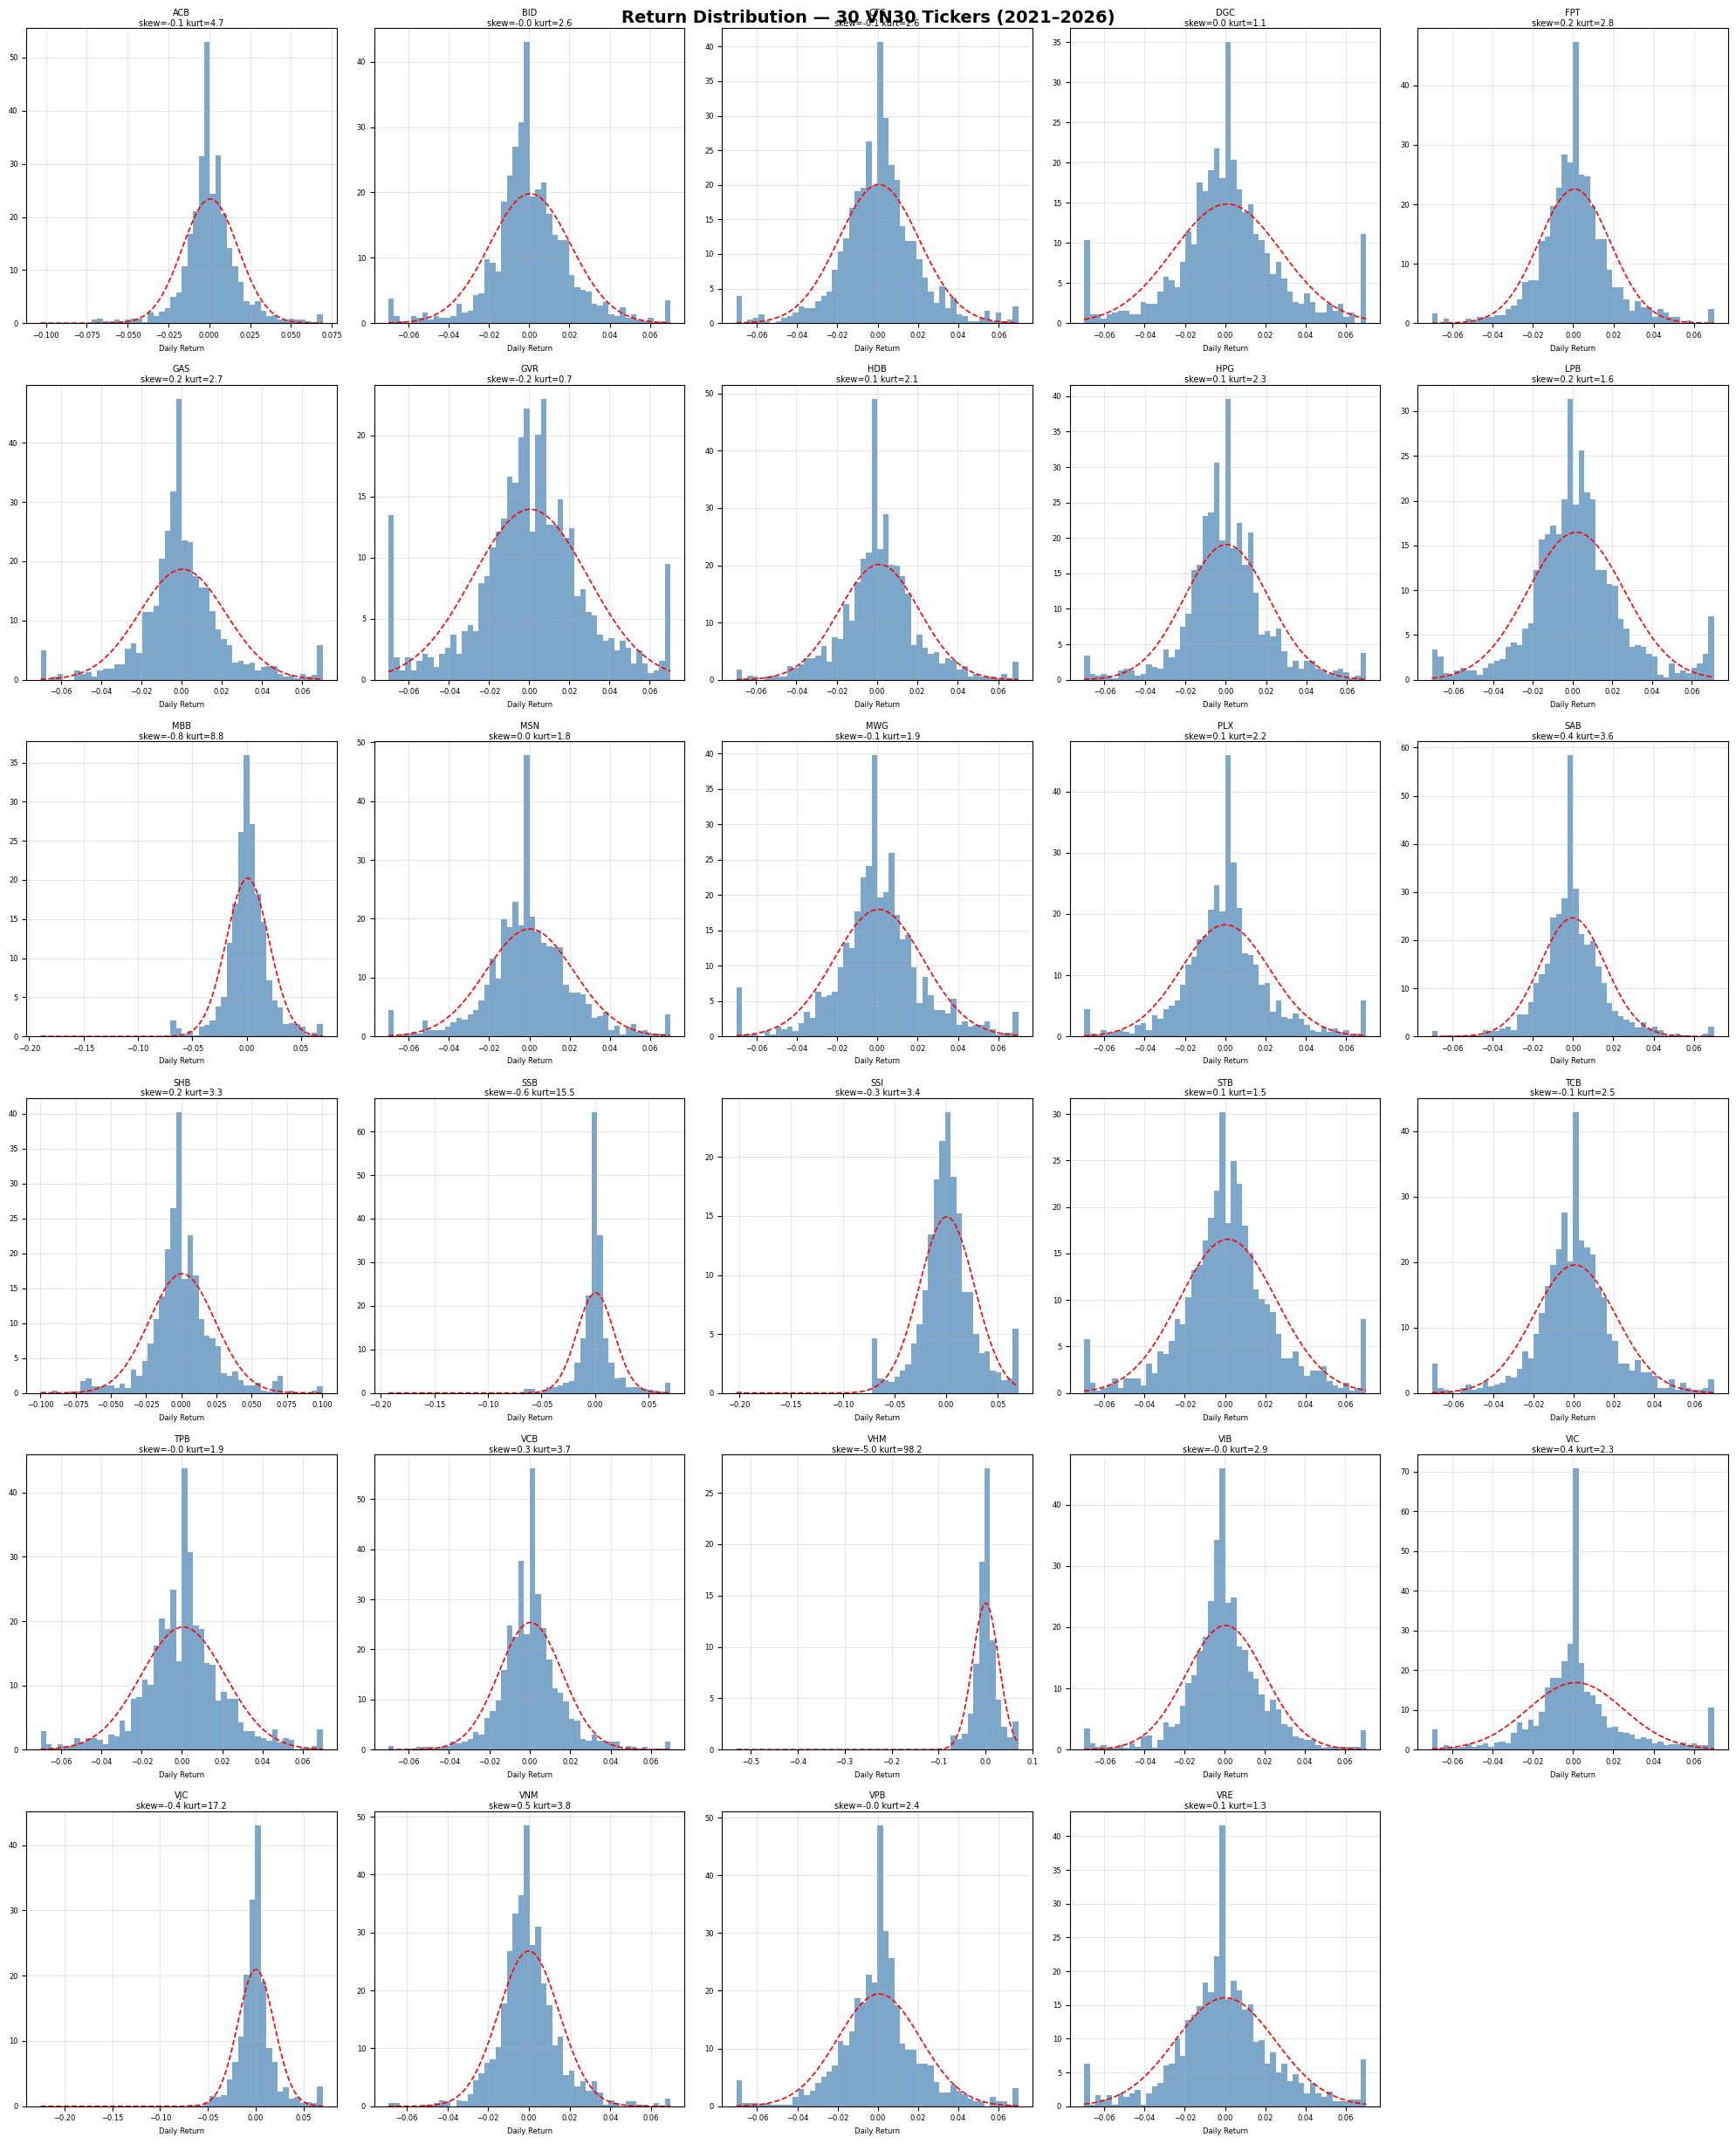

✅ Saved to reports/return_distributions_30tickers2108.png


In [47]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS
import numpy as np
from scipy import stats

# Build returns matrix 30 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-08-21')

# Plot 30 histograms
fig = plt.figure(figsize=(20, 25))
fig.suptitle('Return Distribution — 30 VN30 Tickers (2021–2026)',
             fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(VN30_TICKERS):
    ax = fig.add_subplot(6, 5, i + 1)
    ret = matrix[ticker].dropna()

    # Histogram
    ax.hist(ret, bins=50, color='steelblue', alpha=0.7, density=True)

    # Normal distribution overlay
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='red', linewidth=1.2, linestyle='--')

    # Skewness và kurtosis
    skew = ret.skew()
    kurt = ret.kurtosis()

    ax.set_title(f'{ticker}\nskew={skew:.1f} kurt={kurt:.1f}',
                 fontsize=7, pad=2)
    ax.set_xlabel('Daily Return', fontsize=6)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/return_distributions_30tickers2108.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/return_distributions_30tickers2108.png")

In [48]:
import sys
import numpy as np
import pandas as pd
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS

# Build returns matrix 30 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-08-21')

# Tính Covariance Matrix — annualized
cov_matrix = matrix.cov() * 252

print("Shape:", cov_matrix.shape)
print("\nDiagonal (Variance của từng mã = Volatility²):")
for ticker in ['VCB', 'HPG', 'VNM', 'VIC']:
    var = cov_matrix.loc[ticker, ticker]
    vol = np.sqrt(var)
    print(f"  {ticker}: Var={var:.4f}, Volatility=√{var:.4f}={vol:.2%}")

print("\nSample — 5×5 góc trên trái:")
print(cov_matrix.iloc[:5, :5].round(4))

Shape: (29, 29)

Diagonal (Variance của từng mã = Volatility²):
  VCB: Var=0.0621, Volatility=√0.0621=24.93%
  HPG: Var=0.1102, Volatility=√0.1102=33.20%
  VNM: Var=0.0558, Volatility=√0.0558=23.62%
  VIC: Var=0.1406, Volatility=√0.1406=37.50%

Sample — 5×5 góc trên trái:
        ACB     BID     CTG     DGC     FPT
ACB  0.0733  0.0497  0.0545  0.0375  0.0349
BID  0.0497  0.1022  0.0702  0.0418  0.0379
CTG  0.0545  0.0702  0.0996  0.0499  0.0406
DGC  0.0375  0.0418  0.0499  0.1822  0.0481
FPT  0.0349  0.0379  0.0406  0.0481  0.0787


Correlation range:
  Min: 0.089
  Max: 0.737
  Mean: 0.366


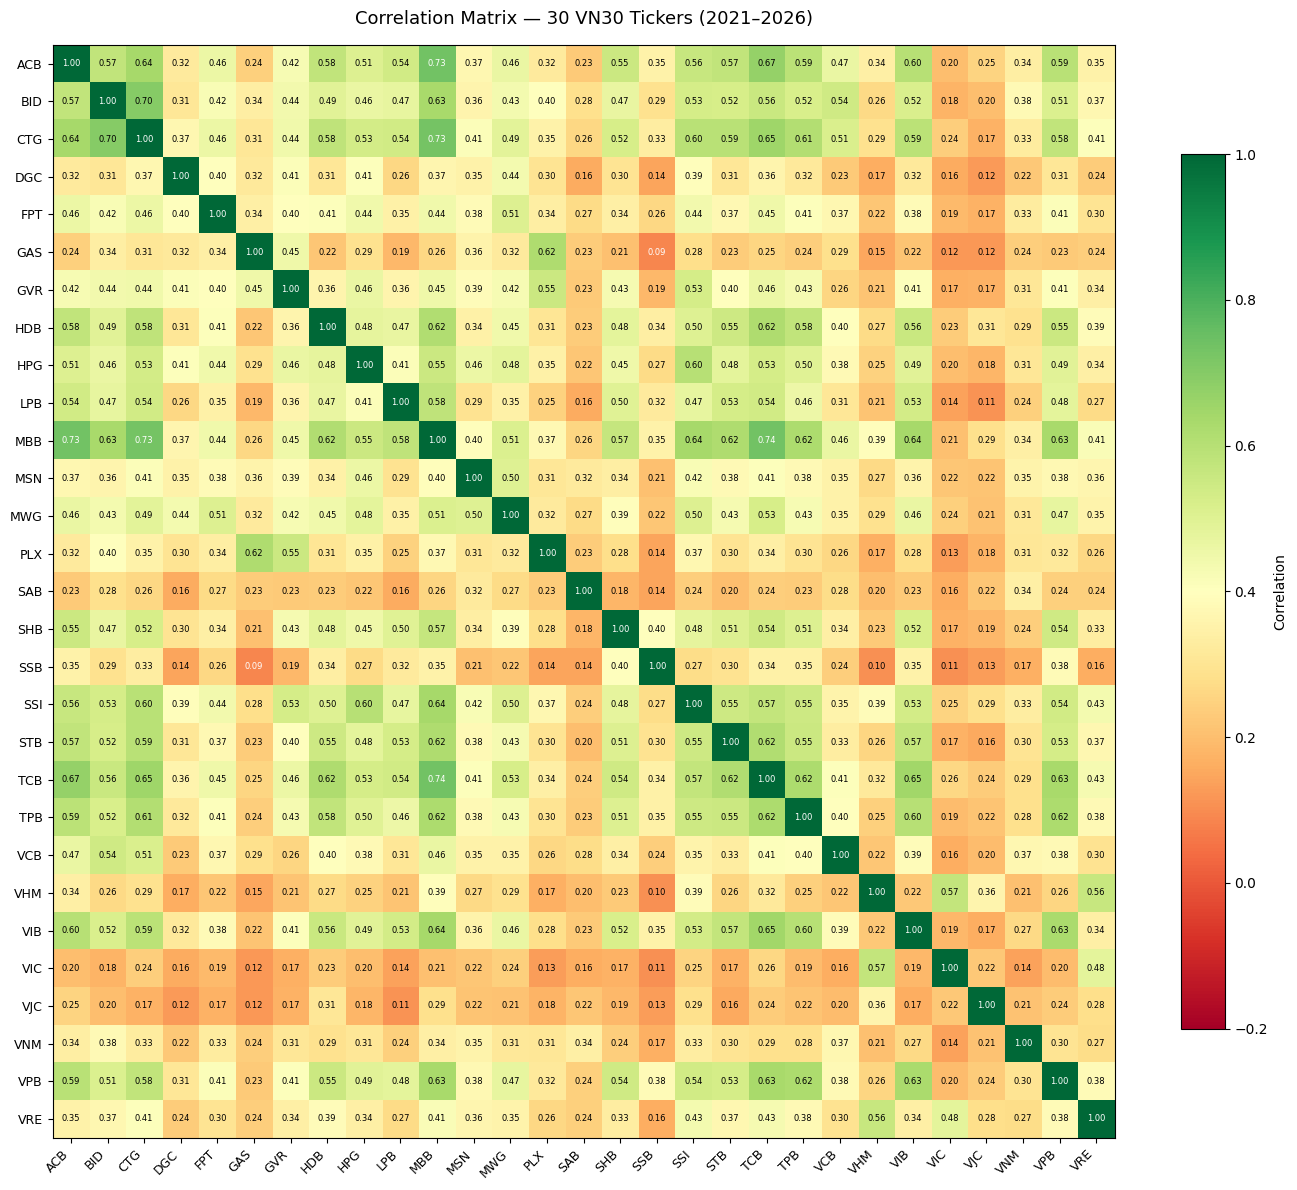

✅ Saved


In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation Matrix
corr_matrix = matrix.corr()

print("Correlation range:")
print(f"  Min: {corr_matrix.values[corr_matrix.values < 1].min():.3f}")
print(f"  Max: {corr_matrix.values[corr_matrix.values < 1].max():.3f}")
print(f"  Mean: {corr_matrix.values[corr_matrix.values < 1].mean():.3f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix.values, cmap='RdYlGn',
               vmin=-0.2, vmax=1.0, aspect='auto')

# Ticks
ax.set_xticks(range(len(VN30_TICKERS)))
ax.set_yticks(range(len(VN30_TICKERS)))
ax.set_xticklabels(VN30_TICKERS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(VN30_TICKERS, fontsize=9)

# Giá trị trong ô
for i in range(len(VN30_TICKERS)):
    for j in range(len(VN30_TICKERS)):
        val = corr_matrix.values[i, j]
        color = 'white' if val > 0.7 or val < 0.1 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Correlation Matrix — 30 VN30 Tickers (2021–2026)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap2108.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

In [50]:
# Tìm cặp tương quan cao nhất và thấp nhất
import itertools

pairs = []
for i, j in itertools.combinations(range(len(VN30_TICKERS)), 2):
    t1, t2 = VN30_TICKERS[i], VN30_TICKERS[j]
    corr = corr_matrix.loc[t1, t2]
    pairs.append({'Ticker1': t1, 'Ticker2': t2, 'Correlation': round(corr, 3)})

df_pairs = pd.DataFrame(pairs).sort_values('Correlation', ascending=False)

print("=== TOP 10 cặp tương quan CAO nhất (diversification kém) ===")
print(df_pairs.head(10).to_string(index=False))

print("\n=== TOP 10 cặp tương quan THẤP nhất (diversification tốt) ===")
print(df_pairs.tail(10).to_string(index=False))

print("\n=== Tương quan trung bình theo nhóm ngành ===")
banks   = ['ACB','BID','CTG','HDB','LPB','MBB','SHB','SSB','STB','TCB','TPB','VCB','VIB','VPB']
others  = ['DGC','FPT','GAS','GVR','HPG','MSN','VIC','MWG','PLX','SAB','SSI','VHM','VIC','VJC','VNM','VRE']

bank_corr  = corr_matrix.loc[banks, banks]
cross_corr = corr_matrix.loc[banks, others]

mask = np.ones(bank_corr.shape, dtype=bool)
np.fill_diagonal(mask, False)
print(f"Ngân hàng vs Ngân hàng : {bank_corr.values[mask].mean():.3f}")
print(f"Ngân hàng vs Ngành khác: {cross_corr.values.mean():.3f}")

=== TOP 10 cặp tương quan CAO nhất (diversification kém) ===
Ticker1 Ticker2  Correlation
    MBB     TCB        0.737
    ACB     MBB        0.734
    CTG     MBB        0.728
    BID     CTG        0.696
    ACB     TCB        0.671
    CTG     TCB        0.651
    TCB     VIB        0.645
    MBB     SSI        0.639
    ACB     CTG        0.638
    MBB     VIB        0.636

=== TOP 10 cặp tương quan THẤP nhất (diversification tốt) ===
Ticker1 Ticker2  Correlation
    LPB     VIC        0.138
    SSB     VJC        0.131
    PLX     VIC        0.129
    DGC     VJC        0.124
    GAS     VIC        0.122
    GAS     VJC        0.119
    LPB     VJC        0.113
    SSB     VIC        0.108
    SSB     VHM        0.105
    GAS     SSB        0.089

=== Tương quan trung bình theo nhóm ngành ===
Ngân hàng vs Ngân hàng : 0.519
Ngân hàng vs Ngành khác: 0.318


In [51]:
import importlib
import portfolio_metrics
importlib.reload(portfolio_metrics)
from portfolio_metrics import (expected_returns, covariance_matrix,
                                portfolio_stats, display_metrics)

START = '2021-01-01'
END   = '2026-08-21'
N     = len(VN30_TICKERS)

# Tính inputs
mu  = expected_returns(VN30_TICKERS, START, END)
cov = covariance_matrix(VN30_TICKERS, START, END)

print("Expected returns — top 5 và bottom 5:")
print(mu.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))
print("...")
print(mu.sort_values(ascending=False).tail(5).apply(lambda x: f"{x:.2%}"))

print(f"\nCovariance Matrix shape: {cov.shape}")
print(f"Diagonal range (Variance): {np.diag(cov.values).min():.4f} – {np.diag(cov.values).max():.4f}")

Expected returns — top 5 và bottom 5:
LPB    45.20%
VIC    33.74%
STB    33.56%
HDB    26.95%
DGC    21.37%
dtype: str
...
VJC     4.10%
VRE     1.47%
PLX     1.37%
VNM    -0.41%
SAB    -4.15%
dtype: str

Covariance Matrix shape: (29, 29)
Diagonal range (Variance): 0.0558 – 0.2062


In [52]:
import importlib
import portfolio_metrics
importlib.reload(portfolio_metrics)
from portfolio_metrics import (expected_returns, covariance_matrix,
                                portfolio_stats, display_metrics)
import numpy as np

START = '2021-01-01'
END   = '2026-08-21'

# ── Test 3 mã verify tay ──────────────────────────────────────
test_tickers = ['VCB', 'VNM', 'HPG']
mu3  = expected_returns(test_tickers, START, END)
cov3 = covariance_matrix(test_tickers, START, END)
w3   = np.array([1/3, 1/3, 1/3])

stats = portfolio_stats(w3, mu3, cov3)

print("=== Python output (VCB + VNM + HPG, equal weights) ===")
print(f"Return    : {stats['port_return']:.6f}  ({stats['port_return']:.2%})")
print(f"Volatility: {stats['port_volatility']:.6f}  ({stats['port_volatility']:.2%})")
print(f"Sharpe    : {stats['sharpe_ratio']:.6f}")
print(f"Variance  : {stats['port_variance']:.6f}")

# ── Tính tay verify ───────────────────────────────────────────
print("\n=== Tính tay verify ===")
r_manual = (mu3['VCB'] + mu3['VNM'] + mu3['HPG']) / 3
print(f"Return tay : {r_manual:.6f}  {'✅' if abs(r_manual - stats['port_return']) < 1e-8 else '❌'}")

var_manual = float(w3 @ cov3.values @ w3)
vol_manual = np.sqrt(var_manual)
print(f"Vol tay    : {vol_manual:.6f}  {'✅' if abs(vol_manual - stats['port_volatility']) < 1e-8 else '❌'}")

sharpe_manual = (r_manual - 0.045) / vol_manual
print(f"Sharpe tay : {sharpe_manual:.6f}  {'✅' if abs(sharpe_manual - stats['sharpe_ratio']) < 1e-8 else '❌'}")

# ── Equal weights 30 mã ───────────────────────────────────────
from data_loader import VN30_TICKERS
N  = len(VN30_TICKERS)
mu = expected_returns(VN30_TICKERS, START, END)
cov = covariance_matrix(VN30_TICKERS, START, END)

w_equal = np.array([1/N] * N)
display_metrics(VN30_TICKERS, w_equal, mu, cov,
                label='Equal Weights — 29 VN30 tickers')

=== Python output (VCB + VNM + HPG, equal weights) ===
Return    : 0.058582  (5.86%)
Volatility: 0.212291  (21.23%)
Sharpe    : 0.063980
Variance  : 0.045067

=== Tính tay verify ===
Return tay : 0.058582  ✅
Vol tay    : 0.212291  ✅
Sharpe tay : 0.063980  ✅

  Equal Weights — 29 VN30 tickers
  Expected Return    :   14.34%
  Volatility (Risk)  :   21.08%
  Sharpe Ratio       :    0.467
Ticker Weight Exp Return
   ACB   3.4%      14.8%
   BID   3.4%      12.7%
   CTG   3.4%      15.3%
   DGC   3.4%      21.4%
   FPT   3.4%      17.2%
   GAS   3.4%      11.5%
   GVR   3.4%      14.0%
   HDB   3.4%      27.0%
   HPG   3.4%       9.4%
   LPB   3.4%      45.2%
   MBB   3.4%      19.5%
   MSN   3.4%       5.3%
   MWG   3.4%      16.5%
   PLX   3.4%       1.4%
   SAB   3.4%      -4.1%
   SHB   3.4%      16.1%
   SSB   3.4%      10.3%
   SSI   3.4%      17.3%
   STB   3.4%      33.6%
   TCB   3.4%      14.6%
   TPB   3.4%      14.0%
   VCB   3.4%       9.3%
   VHM   3.4%      10.8%
   VIB   3.

,Ticker,Weight,Exp Return
0,ACB,3.4%,14.8%
1,BID,3.4%,12.7%
2,CTG,3.4%,15.3%
3,DGC,3.4%,21.4%
4,FPT,3.4%,17.2%
5,GAS,3.4%,11.5%
6,GVR,3.4%,14.0%
7,HDB,3.4%,27.0%
8,HPG,3.4%,9.4%
9,LPB,3.4%,45.2%


In [53]:
import sys, importlib
sys.path.append('../src')

# Reload để lấy code mới nhất
import optimizer
importlib.reload(optimizer)
from optimizer import min_variance_portfolio, display_portfolio

START = '2021-01-01'
END   = '2026-08-21'

# Test 1: 5 mã đa dạng ngành
tickers_5 = ['VCB', 'VNM', 'HPG', 'FPT', 'MWG']
result_5   = min_variance_portfolio(tickers_5, START, END)
display_portfolio(result_5, '5 mã đa ngành')

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------

  5 mã đa ngành
  Portfolio Return    :    7.10%
  Portfolio Volatility:   19.64%
  Sharpe Ratio        :    0.132
───────────────────────────────────────────────────────
  Equal Weights Vol   :   21.46%  (baseline)
  Volatility Reduction:     8.5%

  Allocation (5 active positions):
  Ticker     Weight   Exp Return
  ──────────────────────────────
  VNM         41.6%        -1.9%
  VCB         31.3%         8.7%
  FPT         17.9%        22.1%
  HPG          6.1%        10.8%
  MWG          3.0%        17.7%
  ──────────────────────────────
  TOTAL      100.0%


,Ticker,Weight%,Exp Ret%
0,VNM,41.6%,-1.9%
1,VCB,31.3%,8.7%
2,FPT,17.9%,22.1%
3,HPG,6.1%,10.8%
4,MWG,3.0%,17.7%


In [54]:
import numpy as np

w = result_5['weights']
print("=== Verification ===")
print(f"sum(weights)     = {w.sum():.8f}  (phải = 1.0)")
print(f"min(weight)      = {w.min():.8f}  (phải >= 0)")
print(f"Optimizer success: {result_5['success']}")
print(f"Portfolio Vol    = {result_5['port_volatility']:.2%}")
print(f"Equal Weights Vol= {result_5['equal_weights_vol']:.2%}")
print(f"Improvement      = {result_5['improvement_pct']:.1f}%")
print(f"\n✅ Vol < baseline: {result_5['port_volatility'] < result_5['equal_weights_vol']}")

=== Verification ===
sum(weights)     = 1.00000000  (phải = 1.0)
min(weight)      = 0.03009813  (phải >= 0)
Optimizer success: True
Portfolio Vol    = 19.64%
Equal Weights Vol= 21.46%
Improvement      = 8.5%

✅ Vol < baseline: True


In [55]:
test_cases = {
    '5 mã đa ngành'  : ['VCB', 'VNM', 'HPG', 'FPT', 'MWG'],
    '5 mã ngân hàng' : ['VCB', 'BID', 'CTG', 'MBB', 'ACB'],
    '10 mã VN30'     : ['VCB','BID','CTG','TCB','MBB',
                         'FPT','VNM','HPG','GAS','VIC'],
    '30 mã VN30'     : None,  # full VN30
}

from data_loader import VN30_TICKERS

rows = []
for label, tickers in test_cases.items():
    t = tickers if tickers else VN30_TICKERS
    try:
        r = min_variance_portfolio(t, START, END)
        rows.append({
            'Tổ hợp'    : label,
            'N mã'      : len(t),
            'MVP Vol'   : f"{r['port_volatility']:.2%}",
            'MVP Return': f"{r['port_return']:.2%}",
            'MVP Sharpe': f"{r['sharpe_ratio']:.3f}",
            'EW Vol'    : f"{r['equal_weights_vol']:.2%}",
            'Giảm Vol'  : f"{r['improvement_pct']:.1f}%",
            'N active'  : int((r['weights'] > 0.001).sum()),
            'Converged' : '✅' if r['success'] else '❌',
        })
    except Exception as e:
        rows.append({'Tổ hợp': label, 'N mã': '?', 'MVP Vol': f'ERROR: {e}',
                     'MVP Return':'', 'MVP Sharpe':'', 'EW Vol':'',
                     'Giảm Vol':'', 'N active':'', 'Converged':'❌'})

import pandas as pd
comparison = pd.DataFrame(rows)
print("\n=== Bảng so sánh tổ hợp danh mục ===")
print(comparison.to_string(index=False))

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------

=== Bảng so sánh tổ hợp danh mục ===
        Tổ hợp  N mã MVP Vol MVP Return MVP Sharpe EW Vol Giảm Vol  N active Converged
 5 mã đa ngành     5  19.64%      7.10%      0.132 21.46%     8.5%         5         ✅
5 mã ngân hàng     5  22.65%     12.06%      0.334 24.84%     8.8%         5         ✅
    10 mã VN30    10  18.66%     10.39%      0.316 21.25%    12.2%         7         ✅
    30 mã VN30    29  15.62%      7.25%      0.176 21.08%    25.9%        11         ✅


In [56]:
# Edge cases
print("=== Edge case tests ===\n")

# Edge 1: 2 mã tương quan cao
r2 = min_variance_portfolio(['VCB', 'BID'])
print(f"2 mã tương quan cao (VCB+BID):")
print(f"  Vol={r2['port_volatility']:.2%} | OK={r2['success']}")
for t, w in zip(r2['tickers'], r2['weights']):
    print(f"  {t}: {w:.1%}")

# Edge 2: bao gồm mã vol cao (HPG, SSI)
print()
r_high = min_variance_portfolio(['VCB','MSN','HPG','SSI','LPB'])
print(f"Bao gồm HPG/SSI vol cao:")
for t, w in zip(r_high['tickers'], r_high['weights']):
    if w > 0.001:
        print(f"  {t}: {w:.1%}")
print(f"  Vol={r_high['port_volatility']:.2%} | OK={r_high['success']}")

print("\n✅ Edge cases done")

=== Edge case tests ===

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
2 mã tương quan cao (VCB+BID):
  Vol=24.51% | OK=True
  VCB: 74.9%
  BID: 25.1%

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
Bao gồm HPG/SSI vol cao:
  VCB: 56.9%
  MSN: 16.3%
  HPG: 14.2%
  LPB: 12.6%
  Vol=22.63% | OK=True

✅ Edge cases done


In [57]:
# DB đang load 29 tickers / 38,979 rows thay vì chỉ 5 mã
# Có thể min_variance_portfolio() đang load toàn bộ DB thay vì filter theo tickers
# Kiểm tra:
print(result_5['tickers'])   # phải là ['VCB','MSN','HPG','SSI','LPB']
print(len(result_5['weights']))  # phải là 5, không phải 29

['VCB', 'VNM', 'HPG', 'FPT', 'MWG']
5


In [58]:
# Trong Jupyter — test mã không có trong DB
try:
    min_variance_portfolio(['VCB', 'INVALID_TICKER'])
except ValueError as e:
    print(f"✅ Bắt lỗi đúng: {e}")

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
✅ Bắt lỗi đúng: Tickers not in DB: ['INVALID_TICKER']. Run update_db() first.


In [59]:
# Test mã hợp lệ vẫn chạy bình thường
r = min_variance_portfolio(['VCB', 'VNM', 'HPG'])
print(f"✅ 3 mã hợp lệ: Vol={r['port_volatility']:.2%}")

---------------------------------------------
No. Tickers : 29
No. Rows    : 40,661
---------------------------------------------
✅ 3 mã hợp lệ: Vol=20.24%
